In [6]:
import glob
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib

import numpy as np

from matplotlib import font_manager

font_dirs = ['/glade/u/home/chayan/myutils/extras/ttf/']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# set font
plt.rcParams['font.family'] = 'Inter'


import sys

sys.path.append('/glade/u/home/chayan/myutils/')

import errormetrics as em

In [7]:
import cmaes
import inspect
print(inspect.signature(cmaes.CMA))

(mean: 'np.ndarray', sigma: 'float', bounds: 'Optional[np.ndarray]' = None, n_max_resampling: 'int' = 100, seed: 'Optional[int]' = None, population_size: 'Optional[int]' = None, cov: 'Optional[np.ndarray]' = None, lr_adapt: 'bool' = False)


In [8]:
import sys

sys.path.append('/glade/u/home/chayan/myutils/')

import errormetrics as em

In [9]:
import numpy as np
from numpy.linalg import inv, det

In [10]:
alldata = pd.read_feather('./alldata_new.feather')

In [11]:
alldata['SOURCE'].unique()

array(['APCC', 'C14', 'RS', 'G20'], dtype=object)

In [12]:
cols = ['BC_3D_AR1',
 'BC_3D_AR2',
 'BC_3D_AR3',
 'BC_3D_AR4',
 'BC_3D_AR5',
 'BC_3D_AR6',
 'BC_3D_AR7',
 'BC_3D_AR8',
 'BC_3D_AR9',
 'BC_3D_AR10',
 'BC_3D_BB',
 'BC_3D_BDRES',
       ]

len(cols)

12

<Axes: >

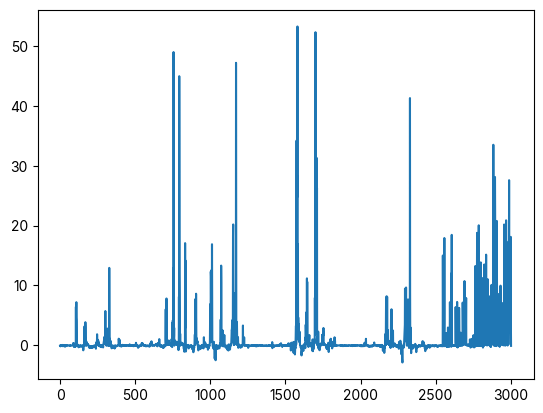

In [13]:
# alldata['BC_3D_RES'] = alldata['BC_3D_TOT'] - alldata[['BC_3D_AR1',
#  'BC_3D_AR2',
#  'BC_3D_AR3',
#  'BC_3D_AR4',
#  'BC_3D_AR5',
#  'BC_3D_AR6',
#  'BC_3D_AR7',
#  'BC_3D_AR8',
#  'BC_3D_AR9',
#  'BC_3D_AR10',
#  'BC_3D_BB',
# 'BC_3D_BDY']].sum(1)

alldata['BC_3D_BDRES'] = alldata['BC_3D_BDY'] + alldata['BC_3D_RES']

alldata['BC_3D_BDRES'].plot()
#alldata['BC_3D_RES']

,SOURCE,SITE,LON,LAT,YEAR,MONTH,DAY,BC_OBS,BC_3D_TOT,BC_3D_BB,...,BC_3D_AR3,BC_3D_AR4,BC_3D_AR5,BC_3D_AR6,BC_3D_AR7,BC_3D_AR8,BC_3D_AR9,BC_3D_AR10,BC_3D_RES,BC_3D_BDRES
0,APCC,Ali(Ngari),79.70,33.83,2015.0,8.0,29.0,0.30,0.019091,0.000209,...,0.012771,0.023693,0.001127,0.009552,2.896461e-09,1.578389e-09,8.718098e-09,0.000637,-0.046944,-0.029009
1,APCC,Ali(Ngari),79.70,33.83,2015.0,9.0,14.0,0.43,0.029525,0.001165,...,0.012341,0.016356,0.001626,0.013039,6.407846e-11,1.392428e-10,4.431389e-09,0.000428,-0.028494,-0.015586
2,APCC,Ali(Ngari),79.70,33.83,2015.0,9.0,20.0,0.02,0.014831,0.002076,...,0.146445,0.009797,0.000447,0.005216,1.675820e-03,1.052380e-03,7.614015e-03,0.003745,-0.179586,-0.163763
3,APCC,Ali(Ngari),79.70,33.83,2015.0,9.0,25.0,0.05,0.012453,0.000209,...,0.011293,0.005415,0.000215,0.006867,1.142564e-04,2.676333e-05,9.124034e-05,0.000324,-0.016712,-0.012286
4,APCC,Ali(Ngari),79.70,33.83,2015.0,10.0,6.0,0.55,0.006162,0.000045,...,0.002089,0.001414,0.000294,0.008895,1.850593e-08,3.197667e-09,1.125148e-08,0.000152,-0.017401,-0.006752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2998,G20,Linan (LA),119.73,30.30,NaN,NaN,NaN,4.14,13.826623,0.054611,...,0.003318,0.000223,0.000030,0.000869,2.420216e-04,3.893798e-03,1.339844e-02,0.097214,10.101510,10.218419
2999,G20,Waliguan (WLG),100.92,36.28,NaN,NaN,NaN,0.38,0.508631,0.003590,...,0.002865,0.001102,0.000198,0.225879,5.762142e-05,1.563679e-04,7.102537e-04,0.003024,0.091226,0.116493
3000,G20,Longfengshan (LFS),127.60,44.73,NaN,NaN,NaN,2.03,19.453836,0.052858,...,0.000125,0.000017,0.000009,0.000150,2.429902e-06,3.562966e-05,7.087668e-04,0.040689,17.987372,18.120750
3001,G20,Akdala (AKDL),87.97,47.12,NaN,NaN,NaN,0.45,3.668457,0.014193,...,0.000144,0.000152,0.000111,0.000199,4.142090e-07,4.483732e-07,1.262294e-06,0.019515,3.358654,3.439665


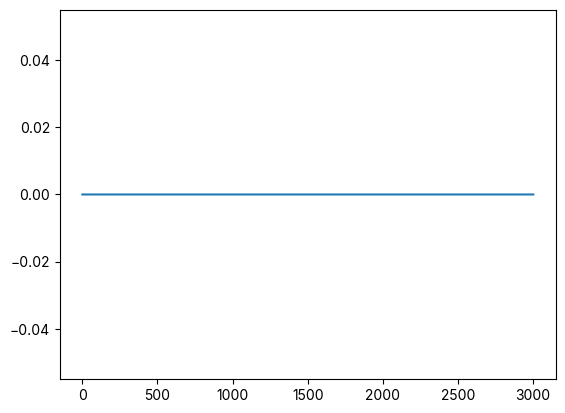

In [14]:
(alldata['BC_3D_TOT'].round(3) - alldata[cols].sum(1).round(3)).plot()

#alldata[cols + ['BC_3D_TOT']] = alldata[cols + ['BC_3D_TOT']].round(3)

alldata

In [15]:
data_sources = ['C14', 'RS','G20'] #APCC

def return_Gd(df, sources = data_sources):

    df = df.query('SOURCE == @sources')
    G1 = df[
  cols
    ].values
    d = df['BC_OBS'].values.reshape(-1,1)
    G = G1.copy()

    assert d.shape[0] == G.shape[0]

    return G,d

In [16]:
import numpy as np
from numpy.linalg import inv, det

def calculate_nrss(y, yhat, sigma):
    """
    Normalized Residual Sum-of-Squares (NRSS)
    y     : observed data (vector)
    yhat  : model predictions (vector)
    sigma : data uncertainties (vector)
    """
    return np.sum((y - yhat)**2) / np.sum(sigma**2)

def calculate_reduced_chi2(y, yhat, sigma, num_params):
    """
    Reduced Chi-Squared Statistic.
    num_params : number of fitted parameters
    """
    N = len(y)
    chi2 = np.sum(((y - yhat) / sigma)**2)
    return chi2 / (N - num_params)

def calculate_posterior_covariance(K, Se, Sa):
    """
    Posterior error covariance matrix:
    S_posterior = (K^T Se^-1 K + Sa^-1)^-1
    K  : Jacobian matrix
    Se : Observation error covariance matrix
    Sa : Prior error covariance matrix
    """
    return inv(K.T @ inv(Se) @ K + inv(Sa))

def calculate_averaging_kernel(K, Se, Sa):
    """
    Averaging Kernel (Resolution Matrix):
    A = (K^T Se^-1 K + Sa^-1)^-1 K^T Se^-1 K
    """
    posterior = calculate_posterior_covariance(K, Se, Sa)
    return posterior @ (K.T @ inv(Se) @ K)

def calculate_dfs(A):
    """
    Degrees of Freedom for Signal (DFS):
    DFS = trace(A)
    """
    return np.trace(A)

def calculate_shannon_info(Sa, S_posterior):
    """
    Shannon Information Content:
    H = 0.5 * ln(|Sa| / |S_posterior|)
    """
    return 0.5 * np.log(det(Sa) / det(S_posterior))

def student_t_cost_and_grad(m, G, d_obs, sigma, nu, Cm_inv, m_prior):
    """
    Returns cost J_obs (Student-t), gradient, and residuals.
    """
    m = m.reshape(-1, 1)
    r = (d_obs - G @ m).ravel()                # residual vector
    s2 = sigma.ravel() ** 2                    # variance per obs

    # ----- Student-t negative log-likelihood ------------------
    one_plus = 1 + (r**2) / (nu * s2)
    J_obs = 0.5 * (nu + 1) * np.log(one_plus).sum()

    # weights for gradient (w_i * r_i)
    w = (nu + 1) / (nu * s2 + r**2)
    grad_obs = -G.T @ (w * r).reshape(-1, 1)   # minus sign → descent dir

    return J_obs, grad_obs, r

In [17]:
import numpy as np
from scipy.optimize import minimize, NonlinearConstraint
import scipy.linalg as SLA


def constrained_bayesian_inversion(
        G, d_obs, m_prior, Cd, Cm,
        lambda_reg=1.0,        # keep, but you will not tune it any more
        optimizer='SLSQP',
        verbose=True,):
    """
    Solve linear Bayesian inversion and **diagnose χ² statistics**.
    The function now returns:
        J_obs   – observation misfit part
        J_prior – prior part
    so that the Optuna objective can push them toward their expected DOF.
    """
    # --- reshape & pre-compute inverses ------------------------------------
    m_prior = np.asarray(m_prior).reshape(-1, 1)
    Cd_inv  = SLA.pinv(Cd)
    Cm_inv  = SLA.pinv(Cm)

    num_obs = d_obs.size
    num_params = m_prior.size

    # --- cost, grad, hess ---------------------------------------------------
    def cost_function(m):
        m = m.reshape(-1, 1)
        innov = d_obs - G @ m
        reg   = m - m_prior
        return 0.5 * (innov.T @ Cd_inv @ innov
                      + lambda_reg * reg.T @ Cm_inv @ reg).squeeze()

    def jac(m):
        m = m.reshape(-1, 1)
        return (G.T @ Cd_inv @ (G @ m - d_obs)
                + Cm_inv @ (m - m_prior)).ravel()

    def hess(_):
        return G.T @ Cd_inv @ G + Cm_inv

    # --- Kalman gain & averaging kernel (unchanged) -------------------------
    gain = Cm @ G.T @ SLA.pinv(G @ Cm @ G.T + Cd)
    avgK = gain @ G
    effective_params = np.trace(avgK)

    # --- nonlinear constraint on diag(A) ------------------------------------
    def ak_constraint(m):
        return np.diag(avgK) - 0.2          # keep your 0.2 floor
    nonlinear_constraint = NonlinearConstraint(ak_constraint, 0, np.inf)

    # --- optimisation -------------------------------------------------------
    bounds = [(0.1, 5)] * m_prior.size

    bounds[0] = (0.75, 5)
    bounds[2] = (0.75, 5)
        
    result = minimize(
        cost_function, m_prior.ravel(), method=optimizer,
        jac=jac, hess=hess if optimizer == 'trust-constr' else None,
        bounds=bounds, constraints=nonlinear_constraint
    )
    
    mhat = result.x.reshape(-1, 1)

    # --- posterior covariance & residuals -----------------------------------
    Cm_hat = Cm - gain @ G @ Cm
    resid  = d_obs - G @ mhat

    # ------------------------------------------------------------------------
    # χ² diagnostics you asked for
    J_obs   = float(resid.T @ Cd_inv @ resid)               # scalar
    J_prior = float((mhat - m_prior).T @ Cm_inv @ (mhat - m_prior))

    # everything below is unchanged bookkeeping ------------------------------
    sigma   = np.sqrt(np.diag(Cd)).reshape(-1, 1)
    nrss    = np.sum(resid**2) / np.sum(sigma**2)
    chi2_red = J_obs / max(d_obs.size - effective_params, 1)

    sign_prior, logdet_prior = np.linalg.slogdet(Cm)
    sign_post,  logdet_post  = np.linalg.slogdet(Cm_hat)
    shannon_info = 0.5 * (logdet_prior - logdet_post) if sign_prior > 0 and sign_post > 0 else np.nan

    # ------------------------------------------------------------------ OBJECTIVE
    # Push χ²_obs / N_obs  and χ²_prior / N_par toward 1; penalise their distance.
    loss = (abs(J_obs   / (d.size - effective_params)         - 1.0) +
            abs(J_prior / (effective_params)   - 1.0))

    predictions_posterior = G @ mhat
    predictions_prior = G @ m_prior

    metrics_posterior = em.ErrorMetrics(predictions = predictions_posterior, observations = d).get_metrics(['KGE'])['KGE']
    metrics_prior = em.ErrorMetrics(predictions = predictions_prior, observations = d).get_metrics(['KGE'])['KGE']

    mean_resid = float((d - predictions_posterior).mean())
    mean_resid_bias = (abs(mean_resid) / np.nanstd(d) )   # ← new term
    
    
    results = dict(
        num_observations = num_obs,
        num_state_parameters =  num_params,
        posterior_mean       = mhat,
        posterior_cov_diag   = np.diag(Cm_hat),
        J_obs                = J_obs,
        J_prior              = J_prior,
        chi2_red             = chi2_red,
        nrss                 = nrss,
        effective_params = effective_params,
        shannon_information  = shannon_info,
        averaging_kernel     = avgK,
        #gain_matrix          = gain,
        data_resolution = np.diagonal(G @ gain),
        KGE_prior  = metrics_prior,
        KGE_posterior = metrics_posterior,
        loss = loss
    )

    if verbose:
        print(f"χ²_obs / N_obs   = {J_obs   / d_obs.size :6.3f}")
        print(f"χ²_prior / N_par = {J_prior / m_prior.size:6.3f}")
        print(f"Reduced χ²       = {chi2_red:6.3f}")
        print(f"Loss             = {loss:6.3f}"),
        print(f"Mean_Res_Bias     = {mean_resid_bias:6.3f}")
    return results


In [20]:
G,d = return_Gd(alldata, sources = ['C14', 'RS'])

m_prior = np.ones(G.shape[1]).reshape(-1,1)

sigma_floor = 0.1 * np.nanmedian(d)        # 5 % floor

obs_error = 1
sig = np.maximum(obs_error * d.squeeze(), sigma_floor)

Cd  = np.diag(sig**2) 

Cd = np.eye(d.size)

prior_error = 1e8

Cm      = np.eye(G.shape[1]) * (prior_error ** 2)

print(G.shape, d.shape, m_prior.shape, Cd.shape, Cm.shape)

(420, 12) (420, 1) (12, 1) (420, 420) (12, 12)


In [21]:
N_OBS = G.shape[0]
N_PARAMS = G.shape[1]

print(N_OBS,N_PARAMS)

420 12


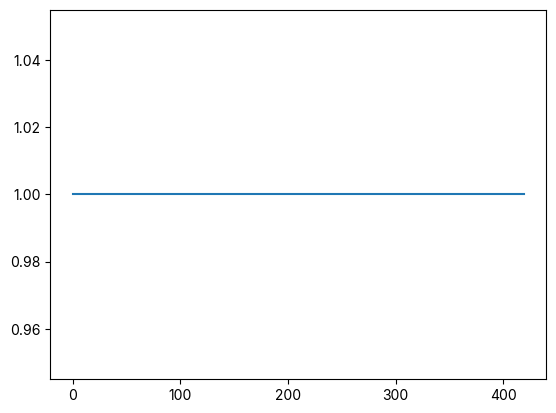

In [22]:
plt.plot(
    np.diagonal(Cd)
)

χ²_obs / N_obs   = 13.315
χ²_prior / N_par =  0.000
Reduced χ²       = 13.707
Loss             = 13.707
Mean_Res_Bias     =  0.298


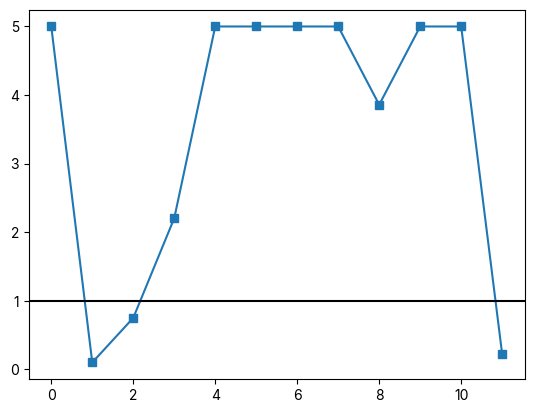

In [27]:
results = constrained_bayesian_inversion(G,d,m_prior, Cd,Cm, optimizer='SLSQP')

plt.plot(results['posterior_mean'], marker = 's')
plt.axhline(1,c='k')

In [28]:
results

{'num_observations': 420,
 'num_state_parameters': 12,
 'posterior_mean': array([[5.        ],
        [0.1       ],
        [0.75      ],
        [2.20348498],
        [4.99999911],
        [5.        ],
        [5.        ],
        [5.        ],
        [3.85852799],
        [5.        ],
        [5.        ],
        [0.22074562]]),
 'posterior_cov_diag': array([ 2.520000e+02,  3.360000e+02, -1.307942e+06, -7.712000e+03,
        -3.983574e+06,  9.800000e+01,  1.820000e+02,  7.508000e+03,
         3.746000e+03, -2.390000e+03, -6.560000e+02, -4.392022e+06]),
 'J_obs': 5592.31505058919,
 'J_prior': 1.2309928866896756e-14,
 'chi2_red': 13.706654535790346,
 'nrss': 13.315035834736168,
 'effective_params': 12.000000000968218,
 'shannon_information': nan,
 'averaging_kernel': array([[ 1.00000000e+00,  5.12495196e-14,  1.36964061e-12,
         -3.45056386e-14,  5.59388495e-12,  1.28232084e-14,
          1.77963484e-14,  8.70560300e-14,  3.78545417e-14,
         -4.30077493e-14, -6.11783453

In [29]:
import sys

sys.path.append('/glade/u/home/chayan/myutils/')

import errormetrics as em

metrics = em.ErrorMetrics(predictions = G @ m_prior, observations = d)

metrics.all_metrics(2)

{'MB': 0.09,
 'RMSE': 5.61,
 'R': 0.55,
 'NMBF': 0.02,
 'NMAEF': 0.83,
 'RNMBF': 0.02,
 'RNMAEF': 0.83,
 'FB': 0.79,
 'FAE': -0.27,
 'FoM': 42.01,
 'Fac2': 43.1,
 'MBD': 2.26,
 'RMSD': 149.24,
 'MAD': 82.6,
 'SDR': 149.22,
 'R²': -0.83,
 'SBF': 0.88,
 'U95': 413.63,
 'TS': 0.31,
 'NSE': -0.83,
 'KGE': 0.24,
 'KGE_R': 0.55,
 'KGE_VAR': 1.61,
 'KGE_MEAN': 1.02,
 'WIA': 0.68,
 'RNP': array([0.58, 0.84, 1.02, 0.62]),
 'LCE': 0.17,
 'ObsMean': 3.76,
 'PredMean': 3.84,
 'ObsMedian': 2.52,
 'PredMedian': 1.43,
 'ObsIQR': 4.1,
 'PredIQR': 3.56,
 'ObsSTD': 4.1,
 'PredSTD': 3.56,
 'KSI': 26.76,
 'OVER': 3.64,
 'CPI': 82.22,
 'RED': 0.76,
 'NMSE': 0.0,
 'CMRSE': 5.61,
 'Rsp': 0.62,
 'LinRho': 0.49,
 'MSD': 31.44,
 'SB': 0.01,
 'NU': 19.39,
 'LC': 12.04,
 'N': 420,
 'EV': -0.83,
 'TSS': 0.26,
 'SS': -0.83,
 'AD': 5158769.23,
 'KLD': 0.6,
 'MPE': 30.4,
 'MAPE': 98.6,
 'sMAPE': 79.37,
 'CRPS': 0.01,
 'TAcc': 64.44}

In [30]:
metrics = em.ErrorMetrics(predictions = G @ results['posterior_mean'], observations = d)

metrics.all_metrics(2)

{'MB': -1.23,
 'RMSE': 3.65,
 'R': 0.61,
 'NMBF': -0.49,
 'NMAEF': 0.86,
 'RNMBF': -0.49,
 'RNMAEF': 0.86,
 'FB': 0.69,
 'FAE': -0.25,
 'FoM': 48.61,
 'Fac2': 51.9,
 'MBD': -32.82,
 'RMSD': 97.12,
 'MAD': 57.81,
 'SDR': 91.41,
 'R²': 0.22,
 'SBF': 0.51,
 'U95': 261.42,
 'TS': 7.35,
 'NSE': 0.22,
 'KGE': 0.47,
 'KGE_R': 0.61,
 'KGE_VAR': 0.85,
 'KGE_MEAN': 0.67,
 'WIA': 0.74,
 'RNP': array([0.55, 0.93, 0.67, 0.7 ]),
 'LCE': 0.42,
 'ObsMean': 3.76,
 'PredMean': 2.52,
 'ObsMedian': 2.52,
 'PredMedian': 1.51,
 'ObsIQR': 4.1,
 'PredIQR': 2.3,
 'ObsSTD': 4.1,
 'PredSTD': 2.3,
 'KSI': 44.98,
 'OVER': 13.4,
 'CPI': 63.16,
 'RED': 0.53,
 'NMSE': 0.16,
 'CMRSE': 3.43,
 'Rsp': 0.7,
 'LinRho': 0.57,
 'MSD': 13.32,
 'SB': 1.52,
 'NU': 0.97,
 'LC': 10.82,
 'N': 420,
 'EV': 0.31,
 'TSS': 0.63,
 'SS': 0.22,
 'AD': 283501.42,
 'KLD': 0.31,
 'MPE': 12.0,
 'MAPE': 75.44,
 'sMAPE': 69.07,
 'CRPS': 0.01,
 'TAcc': 66.35}

In [34]:
def prepare_inversion(G,d):
    m_prior = np.ones(G.shape[1]).reshape(-1,1)

    # sigma_floor = 0.1 * np.nanmedian(d)        # 10 % floor
    # obs_error = 0.1
    # sig = np.maximum(obs_error * d.squeeze(), sigma_floor)
    # Cd  = np.diag(sig**2)

    Cd = np.eye(d.size) # R = I
    
    prior_error = 1e6
    Cm = np.eye(G.shape[1]) * (prior_error ** 2) # B == inf

    return m_prior, Cd, Cm

# plt.plot(
#     results['data_resolution']
# )

In [35]:
import warnings

warnings.simplefilter("ignore", category=RuntimeWarning)

In [36]:
# # cols[:], 0.05 * np.nanmedian(
# #     np.where(d < np.nanpercentile(d,100), d, np.nan)
# #     )

# obs_error = 1

# floor = 0.1 * np.nanmedian(
# np.where(d < np.nanpercentile(d,100), d, np.nan)
# )

# sigmad = np.maximum(obs_error * d.squeeze(), floor)

# plt.plot(obs_error * d.squeeze())
# plt.axhline(floor)

# floor

In [103]:
import optuna
import numpy as np
import sqlite3
from optuna.samplers import TPESampler, CmaEsSampler, BaseSampler
from optuna.trial import Trial
from optuna.pruners import BasePruner
import typing
import sqlite3
import time
from joblib import Parallel,delayed

class DuplicateIterationPruner(BasePruner):
    def prune(self, study: "optuna.study.Study", trial: "optuna.trial.FrozenTrial") -> bool:
        completed_trials = study.get_trials(states=[optuna.trial.TrialState.COMPLETE])
        for completed_trial in completed_trials:
            if completed_trial.params == trial.params:
                return True
        return False

class SwitchingSampler(optuna.samplers.BaseSampler):
    def __init__(self, switch_trial=30, seed=None):
        """
        Custom sampler that switches from TPE to CMA-ES
        
        Args:
            switch_trial (int): Trial number to switch from TPE to CMA-ES
            seed (int): Random seed for reproducibility
        """
        self._tpe = TPESampler(seed=seed, multivariate=True, group=True)
        self._cmaes = CmaEsSampler(seed=seed, consider_pruned_trials=False)
        self._switch_trial = switch_trial
        
    def infer_relative_search_space(self, study, trial):
        """Defines the search space for the trial."""
        if trial.number <= self._switch_trial:
            return self._tpe.infer_relative_search_space(study, trial)
        return self._cmaes.infer_relative_search_space(study, trial)
    
    def sample_relative(self, study, trial, search_space):
        """Samples parameters for the trial."""
        if trial.number <= self._switch_trial:
            return self._tpe.sample_relative(study, trial, search_space)
        return self._cmaes.sample_relative(study, trial, search_space)
    
    def sample_independent(self, study, trial, param_name, param_distribution):
        """Samples independent parameters."""
        if trial.number <= self._switch_trial:
            return self._tpe.sample_independent(study, trial, param_name, param_distribution)
        return self._cmaes.sample_independent(study, trial, param_name, param_distribution)



class MultiplePruners(optuna.pruners.BasePruner):

    def __init__(
        self,
        pruners: typing.Iterable[optuna.pruners.BasePruner],
        pruning_condition: str = "any",
    ) -> None:

        self._pruners = tuple(pruners)

        self._pruning_condition_check_fn = None
        if pruning_condition == "any":
            self._pruning_condition_check_fn = any
        elif pruning_condition == "all":
            self._pruning_condition_check_fn = all
        else:
            raise ValueError(f"Invalid pruning ({pruning_condition}) condition passed!")
        assert self._pruning_condition_check_fn is not None

    def prune(
        self,
        study: optuna.study.Study,
        trial: optuna.trial.FrozenTrial,
    ) -> bool:

         return self._pruning_condition_check_fn(pruner.prune(study, trial) for pruner in self._pruners)

class EarlyStoppingPruner(optuna.pruners.BasePruner):
    """Prunes trials if no improvement after patience trials"""
    def __init__(self, min_trials=10, patience=5, min_delta=0.001):
        self.min_trials = min_trials
        self.patience = patience
        self.min_delta = min_delta
        self.best_value = float('inf')
        self.no_improvement_count = 0
        
    def prune(self, study: "optuna.study.Study", trial: "optuna.trial.FrozenTrial") -> bool:
        if trial.number < self.min_trials:
            return False
            
        current_value = trial.value
        if current_value is None:
            return False
            
        if current_value < self.best_value - self.min_delta:
            self.best_value = current_value
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            
        return self.no_improvement_count >= self.patience



def make_serializable(obj):
    if isinstance(obj, dict):
        return {key: make_serializable(value) for key, value in obj.items()}
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.bool_):  # <-- Add this line
        return bool(obj)
    return obj


def objective(trial):
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning) 

    #print(f"PID {os.getpid()} running trial {trial.number}")
    
    # obs_instrument_error = trial.suggest_float('obs_instrument_error', 0.05, 0.20, step=0.025) # instrument error
    # obs_rep_error = trial.suggest_float('obs_rep_error', 0.1, 0.4, step = 0.025) # model representetiveness error
    # obs_trans_error = trial.suggest_float('obs_trans_error', 0.1, 0.4, step = 0.025) # model transport, random bias

    obs_error = trial.suggest_float('obs_error', 0.1, 5, step=0.05) # instrument error

    obs_error_floor = trial.suggest_float('obs_error_floor', 0.01, 0.1, step=0.01)

    prior_error_dict = {}
    for i in range(1, N_PARAMS+1):
        prior_error_dict[f'prior_m_{i}'] = trial.suggest_float(f'prior_m_{i}', 0.2, 10, log=True)

    G, d = return_Gd(alldata,  ['C14', 'RS'])

    m_prior, Cd, Cm = prepare_inversion(G, d)

    #########################

    Cm = np.eye(G.shape[1])
    # Multiply all other diagonal elements by c_rest
    for i in range(1, N_PARAMS+1):
        Cm[i-1, i-1] *= (prior_error_dict[f'prior_m_{i}'] * m_prior[i-1]) ** 2

    floor = obs_error_floor * np.nanmedian(d)
    sigmad = np.maximum(obs_error * d.squeeze(), floor)
    #cap = 3*np.nanmedian(d)
    #sigmad = np.minimum(sigmad,cap)
    Cd = np.diag(sigmad ** 2)

    inversion_results = constrained_bayesian_inversion(
        G=G, d_obs=d, m_prior=m_prior, Cd=Cd, Cm=Cm, verbose=False)

    loss = inversion_results['loss'] #+ (0.2 * abs(mean_resid) / np.nanstd(d))   # ← new term of bias residual

    # Convert your results dictionary to JSON serializable format
    serialization_results = make_serializable(inversion_results)

    trial.set_user_attr("results", serialization_results)

    predictions_posterior = G @ inversion_results['posterior_mean']
    predictions_prior = G @ m_prior

    metric = 'KGE'

    metrics_posterior = em.ErrorMetrics(predictions = predictions_posterior, observations = d).get_metrics([metric])[metric]
    trial.set_user_attr(f"{metric}_posterior", metrics_posterior)
    
    metrics_prior = em.ErrorMetrics(predictions = predictions_prior, observations = d).get_metrics([metric])[metric]
    trial.set_user_attr(f"{metric}_prior", metrics_prior)

    metric_diff = metrics_posterior - metrics_prior

    # if metric_diff > 0:
    #     # #raise optuna.TrialPruned()
    #     trial.set_user_attr("state", "FAIL")
    #     # raise RuntimeError(
    #     #     f"Posterior {metric} {metrics_posterior} < prior {metric} {metrics_prior}"
    #     # )

    #     #return np.inf
    #     raise optuna.TrialPruned()

    # 2. Soft bias penalty in objective
    #mean_resid = float((d - G @ inversion_results['posterior_mean']).mean())
    
    #loss = (1 * abs(mean_resid))

    # # 2 Form S = H B Hᵀ + R  (efficient via Woodbury if N≫M)
    # S = G @ Cm @ G.T + Cd
    # cholS = np.linalg.cholesky(S)
    # logdetS = 2*np.sum(np.log(np.diag(cholS)))
    # y = SLA.cho_solve((cholS, True), d)

    # # 3 Negative log-evidence = ½[ ln|S| + dᵀ S⁻¹ d ]
    # loss = 0.5*(logdetS + d.T @ y)

    trial.set_user_attr("state", "PASS")

    #if metric_diff > 0:
    #    loss += metric_diff

    return loss, -metrics_posterior




#####################################

In [104]:
optuna.__version__

'4.3.0'

In [61]:
# study_name = 'tpe_cmaes_seasonal_cost'
# storage_path = '/glade/u/home/chayan/NASA_HMA_ouputs/INVERSION/New/inversion2/db_trials/'
# storage_name = f"sqlite:///{storage_path}{study_name}.db"

# study = optuna.load_study(study_name=study_name, storage=storage_name)


In [60]:
# import cmaes
# import inspect
# print(inspect.signature(cmaes.CMA))

In [105]:
from optuna.storages import RDBStorage

storage_name = RDBStorage(
        url="postgresql+psycopg2://localhost/optuna_db",
    #url = "mysql://root@localhost/example",
        engine_kwargs=dict(pool_size=20, max_overflow=0, pool_pre_ping=True),
    )

study_name = "tpe_cmaes_seasonal_cost_final"

study = optuna.create_study(
        study_name      = study_name,
        directions       = ["minimize","minimize"],
        storage         = storage_name,
        load_if_exists  = True,
        sampler         = SwitchingSampler(switch_trial=5000, seed=5),
        pruner          = MultiplePruners(
            (DuplicateIterationPruner(),
                 )
        ),
    )

# study.enqueue_trial(
# {'obs_error': 0.15000000000000002,
#  'obs_error_floor': 0.09999999999999999,
#  'prior_m_1': 3.6000000000000005,
#  'prior_m_2': 9.35,
#  'prior_m_3': 6.250000000000001,
#  'prior_m_4': 9.9,
#  'prior_m_5': 6.4,
#  'prior_m_6': 6.800000000000001,
#  'prior_m_7': 1.6500000000000001,
#  'prior_m_8': 2.6000000000000005,
#  'prior_m_9': 1.7,
#  'prior_m_10': 8.9,
#  'prior_m_11': 7.000000000000001,
#  'prior_m_12': 7.000000000000001}
#                     )

/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(


In [106]:

study.optimize(objective, n_trials=5, show_progress_bar=True, catch=(RuntimeError,), 
                   #callbacks=[stop_when_target_reached]
                  )


  0%|          | 0/5 [00:00<?, ?it/s]

In [96]:
len(study.trials)

4

In [90]:
# optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
from optuna.logging import set_verbosity, WARNING

# Only warnings and errors will be logged; all INFO/DEBUG is suppressed
set_verbosity(WARNING)

best_value = None

def print_if_new_best(study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
    global best_value

    # Only act on completed trials
    if trial.state is not optuna.trial.TrialState.COMPLETE:
        return

    val = trial.value
    # On the very first complete trial, or whenever we find an improvement...
    if best_value is None or val < best_value:
        best_value = val
        print(f"\n🎉 New best trial #{trial.number}:")
        print(f"    Value:  {val:.5f}")
        print(f"    Params: {trial.params}")


####################################################################
# 0.  Choose the threshold you really care about
TARGET_LOSS = -0.8          #  <-- adjust once you’re sure this makes sense
MAX_TRIALS  = 1000
####################################################################

def stop_when_target_reached(study: optuna.study.Study,
                             trial: optuna.trial.FrozenTrial) -> None:
    """Callback that stops the whole study as soon as we’re good enough."""
    if trial.state != optuna.trial.TrialState.COMPLETE:
        return                          # ignore pruned / failed trials
    if len(study.trials) >= MAX_TRIALS:
        print(f'Max trials reached, {MAX_TRIALS} trials...')
        study.stop()
        
    # if study.best_value is not None and study.best_value <= TARGET_LOSS:
    #     print(f"\n🎯  Target {TARGET_LOSS} reached (best = {study.best_value:.4f})")
    #     study.stop()                    # <-- graceful global stop


import uuid

def optimize_parameters(n_trials, study_name = study_name):

    # derive a unique seed per worker
    unique_seed = int.from_bytes(uuid.uuid4().bytes[:4], 'little')
    
    #sampler = SwitchingSampler(switch_trial=int(MAX_TRIALS * 0.50), seed=unique_seed)
    # sampler = CmaEsSampler(seed=unique_seed, restart_strategy="ipop",
    #     inc_popsize=2)

    sampler = TPESampler(seed=unique_seed, multivariate=True, group=True)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study = optuna.create_study(
        study_name      = study_name,
        directions       = ["minimize","minimize"],
        storage         = storage_name,
        load_if_exists  = True,
        sampler         = sampler,
        pruner          = MultiplePruners(
            (DuplicateIterationPruner(),
                 )
        ),
    )
    
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, catch=(RuntimeError,), 
                   #callbacks=[stop_when_target_reached]
                  )


#################################################################
# Run parallel optimization
n_of_jobs = 10
n_trial_per_job = MAX_TRIALS // n_of_jobs



# n_of_jobs = 1
# n_trial_per_job = 1

print(f'Trials asked : {n_of_jobs * n_trial_per_job} ; {n_trial_per_job} trials across {n_of_jobs} workers.')
print('='*100)
time.sleep(2)

# Add error handling for parallel execution
try:
    r = Parallel(n_jobs=n_of_jobs, backend='loky',verbose=1)(
        delayed(optimize_parameters)(n_trial_per_job) for _ in range(n_of_jobs)
    )
except Exception as e:
    print(f"Parallel execution failed with error: {e}")

print('='*100)
print('DONE')


Trials asked : 1000 ; 100 trials across 10 workers.


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/s

In [69]:
from optuna.storages import RDBStorage

#load the existing study by its study_name
study = optuna.load_study(study_name=study_name, storage=storage_name)


In [101]:
delete = True

if delete:
    #optuna.delete_study(study_name = "tpe_cmaes_seasonal_cost", storage = storage)
    optuna.delete_study(study_name = study_name, storage = storage_name)

In [123]:
trials = study.get_trials(deepcopy=False)
completed_trials = list(
    [
        trial
        for trial in trials
        if trial.state not in {optuna.trial.TrialState.RUNNING, optuna.trial.TrialState.WAITING, optuna.trial.TrialState.FAIL} and trial.number < 2500
    ]
)
if len(trials) != len(completed_trials):
    print(f"Some trials are not completed, will keep {len(completed_trials)} out of {len(trials)}")
    optuna.delete_study(study_name="tpe_cmaes_seasonal_cost", storage=storage_name)
    study = optuna.create_study(
        study_name="tpe_cmaes_seasonal_cost", storage=storage_name,
        load_if_exists=True,
        direction="minimize",
    )
    study.add_trials(completed_trials)

In [129]:
df = study.trials_dataframe().drop(columns = ['datetime_start','datetime_complete','duration'])
df.query('state == "COMPLETE"')

,number,value,params_obs_error,params_obs_error_floor,params_prior_m_1,params_prior_m_10,params_prior_m_11,params_prior_m_12,params_prior_m_2,params_prior_m_3,...,params_prior_m_5,params_prior_m_6,params_prior_m_7,params_prior_m_8,params_prior_m_9,user_attrs_KGE_posterior,user_attrs_KGE_prior,user_attrs_results,user_attrs_state,state


In [63]:
df.query('state == "FAIL"')

,number,value,params_obs_error,params_obs_error_floor,params_prior_m_1,params_prior_m_10,params_prior_m_11,params_prior_m_12,params_prior_m_2,params_prior_m_3,...,user_attrs_results,user_attrs_state,system_attrs_cma:generation,system_attrs_cma:large_n_eval,system_attrs_cma:n_restarts,system_attrs_cma:n_restarts_with_large,system_attrs_cma:popsize,system_attrs_cma:poptype,system_attrs_cma:small_n_eval,state


In [90]:
import optuna
import matplotlib.pyplot as plt

def plot_optimization_history(study):
    # Get all trials
    trials = study.trials

    # Extract trial numbers, objective values, and parameter values
    trial_numbers = [trial.number for trial in trials]
    objective_values = [trial.value for trial in trials if trial.value is not None or not np.isfinite(trial.value)]
    params = {key: [trial.params[key] for trial in trials if key in trial.params] for key in trials[0].params.keys()}

    best_values = []
    current_best = objective_values[0]
    for trial in trials:
        if trial.value is not None:
            if trial.value < current_best:
                current_best = trial.value
        best_values.append(current_best)


    # Plot objective value evolution
    plt.figure(figsize=(12, 4))
    
    plt.plot(trial_numbers[:], best_values, c='r', lw=2)
    
    plt.plot(trial_numbers[:len(objective_values)], 
             objective_values, 
             marker='s',
             markerfacecolor = 'none',
             linestyle='-', 
             color='b',
             markersize=2,
             lw=0.1)
    
    plt.ylim(np.min(objective_values)*0.5, np.nanstd(objective_values) * 5)
    
    plt.xlabel('Trial Number')
    plt.ylabel('Objective Value')
    plt.title('Objective Value Evolution')
    plt.grid(True)
    plt.show()

# Example usage
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=100)
# plot_optimization_history(study)


# Additional function to print best parameters
def print_optimization_summary(study):
    """
    Print summary of optimization results.
    """
    print("\nOptimization Summary:")
    print("-" * 50)
    print('Best trial number : ',study.best_trial.number)
    print(f"Best objective value: {study.best_value:.3f}")
    print("\nBest parameters:")
    for key, value in study.best_params.items():
        print(f"{key}: {value:.2f}")
    
    # Get all trials that succeeded (value != penalty)
    successful_trials = [t for t in study.trials if t.value != np.inf and t.state.name == 'COMPLETE']
    print(f"\nNumber of successful and complete trials: {len(successful_trials)}/{len(study.trials)}")



def analyze_parameter_convergence(study):
    """Analyze how parameters converge over trials."""
    param_history = {}
    
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            for param_name, param_value in trial.params.items():
                if param_name not in param_history:
                    param_history[param_name] = []
                param_history[param_name].append(param_value)
    
    # Create convergence plots for each parameter
    n_params = len(param_history)
    fig, axes = plt.subplots(
        (n_params + 1) // 2, 2, 
        figsize=(15, 3 * ((n_params + 1) // 2))
    )
    axes = axes.ravel()
    
    for idx, (param_name, values) in enumerate(param_history.items()):
        ax = axes[idx]
        ax.plot(values, 'b.-', alpha=0.5)
        ax.set_title(f'{param_name} Convergence')
        ax.set_xlabel('Trial number')
        ax.set_ylabel('Parameter value')
        
        # Add rolling mean
        window = min(10, len(values))
        rolling_mean = pd.Series(values).rolling(window=window).mean()
        ax.plot(rolling_mean, 'r-', linewidth=2, label=f'{window}-trial moving average')
        ax.legend()
    
    plt.tight_layout()
    return fig


In [91]:
print_optimization_summary(study)


Optimization Summary:
--------------------------------------------------
Best trial number :  776
Best objective value: -0.430

Best parameters:
obs_error: 0.10
obs_error_floor: 0.10
prior_m_1: 0.53
prior_m_2: 2.06
prior_m_3: 4.22
prior_m_4: 1.99
prior_m_5: 0.44
prior_m_6: 0.49
prior_m_7: 0.25
prior_m_8: 1.45
prior_m_9: 0.35
prior_m_10: 3.26
prior_m_11: 6.94
prior_m_12: 0.63

Number of successful and complete trials: 2000/2000


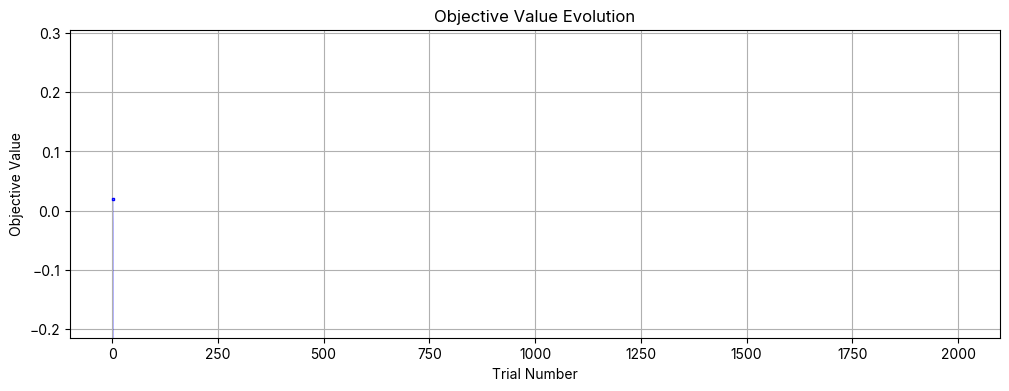

In [92]:
plot_optimization_history(study)

In [93]:
study.best_trial

FrozenTrial(number=776, state=TrialState.COMPLETE, values=[-0.43], datetime_start=datetime.datetime(2025, 5, 21, 15, 21, 32, 797101), datetime_complete=datetime.datetime(2025, 5, 21, 15, 21, 33, 408434), params={'obs_error': 0.1, 'obs_error_floor': 0.09999999999999999, 'prior_m_1': 0.5281944863727184, 'prior_m_2': 2.058448231624837, 'prior_m_3': 4.221964054567224, 'prior_m_4': 1.994800229761838, 'prior_m_5': 0.44242073154116596, 'prior_m_6': 0.48508707293450515, 'prior_m_7': 0.24754146166442972, 'prior_m_8': 1.4531342975050054, 'prior_m_9': 0.3537887740923302, 'prior_m_10': 3.2595050760368145, 'prior_m_11': 6.935934491412006, 'prior_m_12': 0.6270491454885669}, user_attrs={'KGE_posterior': 0.43, 'KGE_prior': -0.02, 'results': {'num_observations': 455, 'num_state_parameters': 12, 'posterior_mean': [[0.75], [0.1], [0.75], [4.052433407969752], [1.1231555377443483], [4.991512532593823], [3.917484224031584], [4.9999973194248994], [1.037396410460437], [0.10000002351455137], [4.999998091529596

In [111]:
study.best_trial.params

{'obs_error': 0.1,
 'obs_error_floor': 0.09999999999999999,
 'prior_m_1': 0.5281944863727184,
 'prior_m_2': 2.058448231624837,
 'prior_m_3': 4.221964054567224,
 'prior_m_4': 1.994800229761838,
 'prior_m_5': 0.44242073154116596,
 'prior_m_6': 0.48508707293450515,
 'prior_m_7': 0.24754146166442972,
 'prior_m_8': 1.4531342975050054,
 'prior_m_9': 0.3537887740923302,
 'prior_m_10': 3.2595050760368145,
 'prior_m_11': 6.935934491412006,
 'prior_m_12': 0.6270491454885669}

In [95]:
# 1. add offset parameter b

G_aug = np.hstack([G, np.ones((G.shape[0],1))])
m_prior_aug = np.vstack([m_prior, [[0.0]]])        # expect zero bias a priori

Cm_aug = SLA.block_diag(Cm, [[0.2**2]])            # prior σ_b = 0.2

results = constrained_bayesian_inversion(
            G_aug, d, m_prior_aug, Cd, Cm_aug, lambda_reg=1, verbose=False)

print("mean bias post =", np.mean(d - G_aug @ results['posterior_mean']))

mean bias post = -1.1187482573842108e-07


In [97]:
results['posterior_mean']

array([[0.75      ],
       [0.1       ],
       [0.75      ],
       [0.1       ],
       [5.        ],
       [3.14903828],
       [5.        ],
       [5.        ],
       [0.1       ],
       [0.1       ],
       [5.        ],
       [0.1       ],
       [1.57958594]])

In [98]:
(383.1099794724094 / (455 - 6.522978775344139)) , ((6.279676439205896 / 6.522978775344139) )

(0.8542466198741939, 0.9627007315955267)

In [99]:
study.best_trial.user_attrs['results']['posterior_mean']

[[0.75],
 [0.1],
 [0.75],
 [4.052433407969752],
 [1.1231555377443483],
 [4.991512532593823],
 [3.917484224031584],
 [4.9999973194248994],
 [1.037396410460437],
 [0.10000002351455137],
 [4.999998091529596],
 [0.10000026639120081]]

In [100]:
best_trial = study.best_trial

inversion_results = best_trial.user_attrs['results']

m_post = np.array(inversion_results['posterior_mean'])

In [101]:
metrics = em.ErrorMetrics(predictions = G @ m_prior, observations = d)

metrics.all_metrics(2)

{'MB': 0.87,
 'RMSE': 6.63,
 'R': 0.49,
 'NMBF': 0.23,
 'NMAEF': 0.98,
 'RNMBF': 0.23,
 'RNMAEF': 0.98,
 'FB': 0.81,
 'FAE': -0.18,
 'FoM': 39.09,
 'Fac2': 41.98,
 'MBD': 22.97,
 'RMSD': 175.23,
 'MAD': 97.64,
 'SDR': 173.72,
 'R²': -1.67,
 'SBF': 0.92,
 'U95': 483.63,
 'TS': 2.82,
 'NSE': -1.67,
 'KGE': -0.02,
 'KGE_R': 0.49,
 'KGE_VAR': 1.86,
 'KGE_MEAN': 1.23,
 'WIA': 0.61,
 'RNP': array([0.51, 0.83, 1.23, 0.6 ]),
 'LCE': 0.02,
 'ObsMean': 3.78,
 'PredMean': 4.65,
 'ObsMedian': 2.63,
 'PredMedian': 1.65,
 'ObsIQR': 4.14,
 'PredIQR': 4.29,
 'ObsSTD': 4.14,
 'PredSTD': 4.29,
 'KSI': 38.44,
 'OVER': 2.41,
 'CPI': 97.83,
 'RED': 1.02,
 'NMSE': 0.04,
 'CMRSE': 6.57,
 'Rsp': 0.6,
 'LinRho': 0.41,
 'MSD': 43.97,
 'SB': 0.76,
 'NU': 30.77,
 'LC': 12.44,
 'N': 455,
 'EV': -1.62,
 'TSS': 0.18,
 'SS': -1.67,
 'AD': 13766499.49,
 'KLD': 0.66,
 'MPE': 54.08,
 'MAPE': 117.93,
 'sMAPE': 81.34,
 'CRPS': 0.01,
 'TAcc': 64.32}

In [103]:
metrics = em.ErrorMetrics(predictions = G @ m_post, observations = d)

metrics.all_metrics(2)

{'MB': -1.33,
 'RMSE': 3.8,
 'R': 0.57,
 'NMBF': -0.54,
 'NMAEF': 0.92,
 'RNMBF': -0.54,
 'RNMAEF': 0.92,
 'FB': 0.73,
 'FAE': -0.33,
 'FoM': 46.86,
 'Fac2': 51.21,
 'MBD': -35.18,
 'RMSD': 100.44,
 'MAD': 59.64,
 'SDR': 94.08,
 'R²': 0.12,
 'SBF': 0.49,
 'U95': 269.73,
 'TS': 7.97,
 'NSE': 0.12,
 'KGE': 0.43,
 'KGE_R': 0.57,
 'KGE_VAR': 0.87,
 'KGE_MEAN': 0.65,
 'WIA': 0.72,
 'RNP': array([0.51, 0.92, 0.65, 0.67]),
 'LCE': 0.4,
 'ObsMean': 3.78,
 'PredMean': 2.45,
 'ObsMedian': 2.63,
 'PredMedian': 1.43,
 'ObsIQR': 4.14,
 'PredIQR': 2.23,
 'ObsSTD': 4.14,
 'PredSTD': 2.23,
 'KSI': 50.63,
 'OVER': 18.63,
 'CPI': 67.53,
 'RED': 0.57,
 'NMSE': 0.19,
 'CMRSE': 3.56,
 'Rsp': 0.67,
 'LinRho': 0.53,
 'MSD': 14.44,
 'SB': 1.77,
 'NU': 1.51,
 'LC': 11.16,
 'N': 455,
 'EV': 0.23,
 'TSS': 0.55,
 'SS': 0.12,
 'AD': 241595.2,
 'KLD': 0.37,
 'MPE': 2.92,
 'MAPE': 72.33,
 'sMAPE': 73.25,
 'CRPS': 0.02,
 'TAcc': 65.86}

In [104]:
def objective_posterior(trial):

    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning) 

    obs_error = trial.params['obs_error']

    obs_error_floor = trial.params['obs_error_floor']

    prior_error_dict = {}
    for i in range(1, N_PARAMS+1):
        prior_error_dict[f'prior_m_{i}'] = trial.params[f'prior_m_{i}']
        
    G, d = return_Gd(alldata,  ['C14', 'RS','G20'])

    m_prior, Cd, Cm = prepare_inversion(G, d)

    #########################

    Cm = np.eye(G.shape[1])
    # Multiply all other diagonal elements by c_rest
    for i in range(1, N_PARAMS+1):
        Cm[i-1, i-1] *= (prior_error_dict[f'prior_m_{i}'] * m_prior[i-1]) ** 2

    floor = obs_error_floor * np.nanmedian(d)
    sigmad = np.maximum(obs_error * d.squeeze(), floor)
    #cap = 3*np.nanmedian(d)
    #sigmad = np.minimum(sigmad,cap)
    Cd = np.diag(sigmad ** 2)


    return Cd,Cm

Cd_best,Cm_best = objective_posterior(best_trial)

In [105]:
residual_post   = d - G @ m_post        # innovation vector

residual_prior   = d - G @ m_prior        # innovation vector

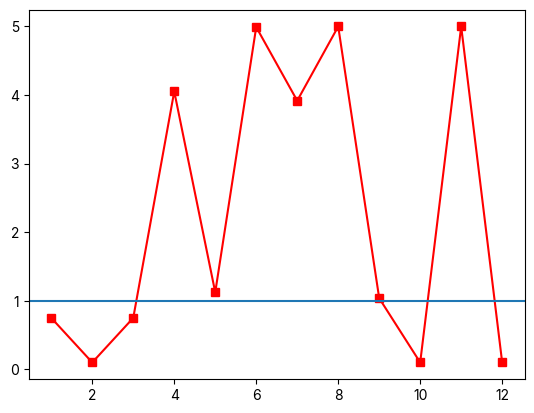

In [106]:
plt.plot([1,2,3,4,5,6,7,8,9,10,11,12], m_post, marker='s',c='r')
plt.axhline(1)

In [107]:
residual   = d - G @ m_post        # innovation vector
sigma_d    = np.sqrt(np.diag(Cd_best))     # 1-σ error at each point
std_resids = residual / sigma_d       # should be N(0,1) if R is correct

residual   = d - G @ m_prior        # innovation vector
sigma_d    = np.sqrt(np.diag(Cd))     # 1-σ error at each point
std_resids_prior = residual / sigma_d       # should be N(0,1) if R is correct


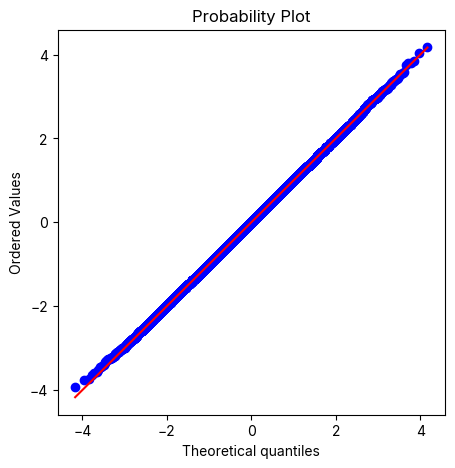

In [108]:
a = np.random.normal(size=455*100) ** 1

import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(5, 5))
res1 = stats.probplot(a, dist="norm", plot=ax)


Text(0, 0.5, 'Sample quantiles')

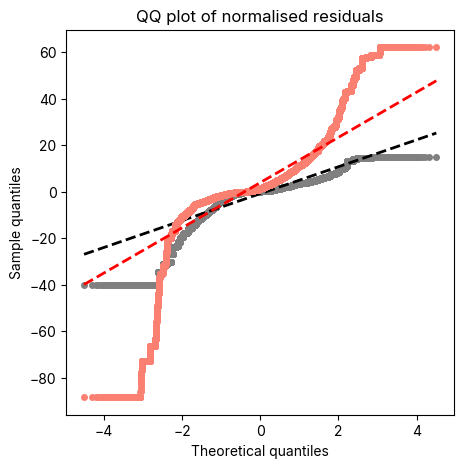

In [109]:
residual   = d - G @ m_post        # innovation vector
sigma_d    = np.sqrt(np.diag(Cd_best))     # 1-σ error at each point
std_resids = residual / sigma_d       # should be N(0,1) if R is correct

residual   = d - G @ m_prior        # innovation vector
sigma_d    = np.sqrt(np.diag(Cd))     # 1-σ error at each point
std_resids_prior = residual / sigma_d       # should be N(0,1) if R is correct

import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(5, 5))
res1 = stats.probplot(std_resids_prior.ravel(), dist="norm", plot=ax)
res2 = stats.probplot(std_resids.ravel(), dist="norm", plot=ax)

ax.get_lines()[0].set_markerfacecolor('grey')
ax.get_lines()[0].set_markeredgecolor('grey')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('k')
ax.get_lines()[1].set_linewidth(2)


ax.get_lines()[2].set_markerfacecolor('salmon')
ax.get_lines()[2].set_markeredgecolor('salmon')
ax.get_lines()[2].set_markersize(4)
ax.get_lines()[3].set_color('r')
ax.get_lines()[3].set_linewidth(2)


# cosmetic tweaks (optional)
ax.get_lines()[1].set_linestyle("--")         # 45° reference line dashed
ax.get_lines()[3].set_linestyle("--")         # 45° reference line dashed

ax.set_title("QQ plot of normalised residuals")
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")

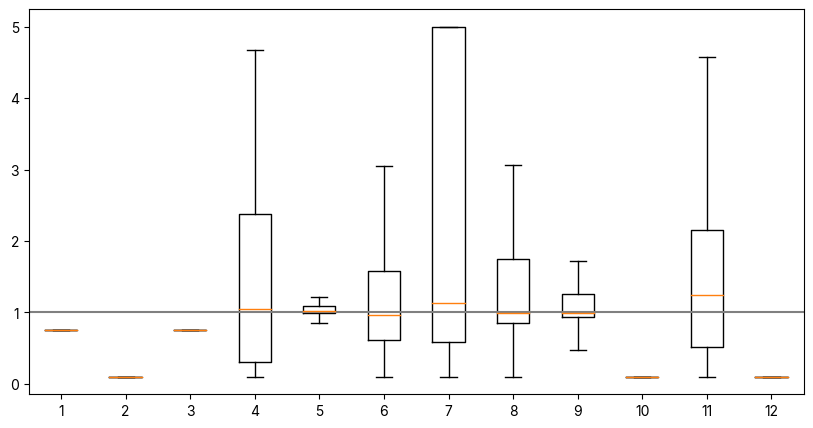

In [110]:
ensemble_m = np.array([t.user_attrs["results"]["posterior_mean"]
                       for t in study.trials[:]  if t.state.name == 'COMPLETE'
                      ])[:,:,0]

np.shape(ensemble_m)

plt.figure(figsize=(10,5))
plt.boxplot(ensemble_m, showfliers=False); #plt.xticks(range(1,13))

plt.axhline(1,c='grey')

In [164]:
param_map = {'obs_error': 'obs_error',
 'prior_m_11': 'prior_BB',
 'prior_m_12': 'prior_BDY',
 'prior_m_13':'prior_RES',
'prior_m_1': 'prior_China',
 'prior_m_2': 'prior_Nepal',
 'prior_m_3': 'prior_India',
 'prior_m_4': 'prior_Pakistan',
 'prior_m_5': 'prior_Afghanistan',
 'prior_m_6': 'prior_Tibetan Plateau',
 'prior_m_7': 'prior_Bangladesh',
 'prior_m_8': 'prior_Myanmar',
 'prior_m_9': 'prior_South-East Asia',
 'prior_m_10': 'prior_Rest of Asia'
}

# "China",
#     "Nepal",
#     "India",
#     "Pakistan",
#     "Afghanistan",
#     "Tibetan Plateau",
#     "Bangladesh",
#     "Myanmar",
#     "South-East Asia",
#     "Rest of Asia",'BB','BDY','RES'

study.best_trial

FrozenTrial(number=6015, state=TrialState.COMPLETE, values=[1.0074888600012923], datetime_start=datetime.datetime(2025, 5, 21, 11, 3, 13, 140513), datetime_complete=datetime.datetime(2025, 5, 21, 11, 3, 13, 620260), params={'obs_error': 0.5, 'obs_error_floor': 0.09999999999999999, 'prior_m_1': 1.034763548600803, 'prior_m_2': 0.3862521916600986, 'prior_m_3': 4.124442052371683, 'prior_m_4': 4.65976948841445, 'prior_m_5': 2.0881396940246506, 'prior_m_6': 2.5588646099162693, 'prior_m_7': 5.527170931168503, 'prior_m_8': 1.3188096221263883, 'prior_m_9': 0.3133350161567274, 'prior_m_10': 3.3793538794306706, 'prior_m_11': 6.2213949664241275, 'prior_m_12': 0.5410290797215026}, user_attrs={'FB_posterior': 0.8, 'FB_prior': 0.81, 'results': {'num_observations': 455, 'num_state_parameters': 12, 'posterior_mean': [[0.75], [0.1000000001348555], [0.75], [1.5398090864052063], [1.1707047470058443], [1.028252790877479], [4.745029974632992], [0.9258029740055462], [0.9925799370296391], [0.10000000007374722

Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...
Max trials reached, 6000 trials...


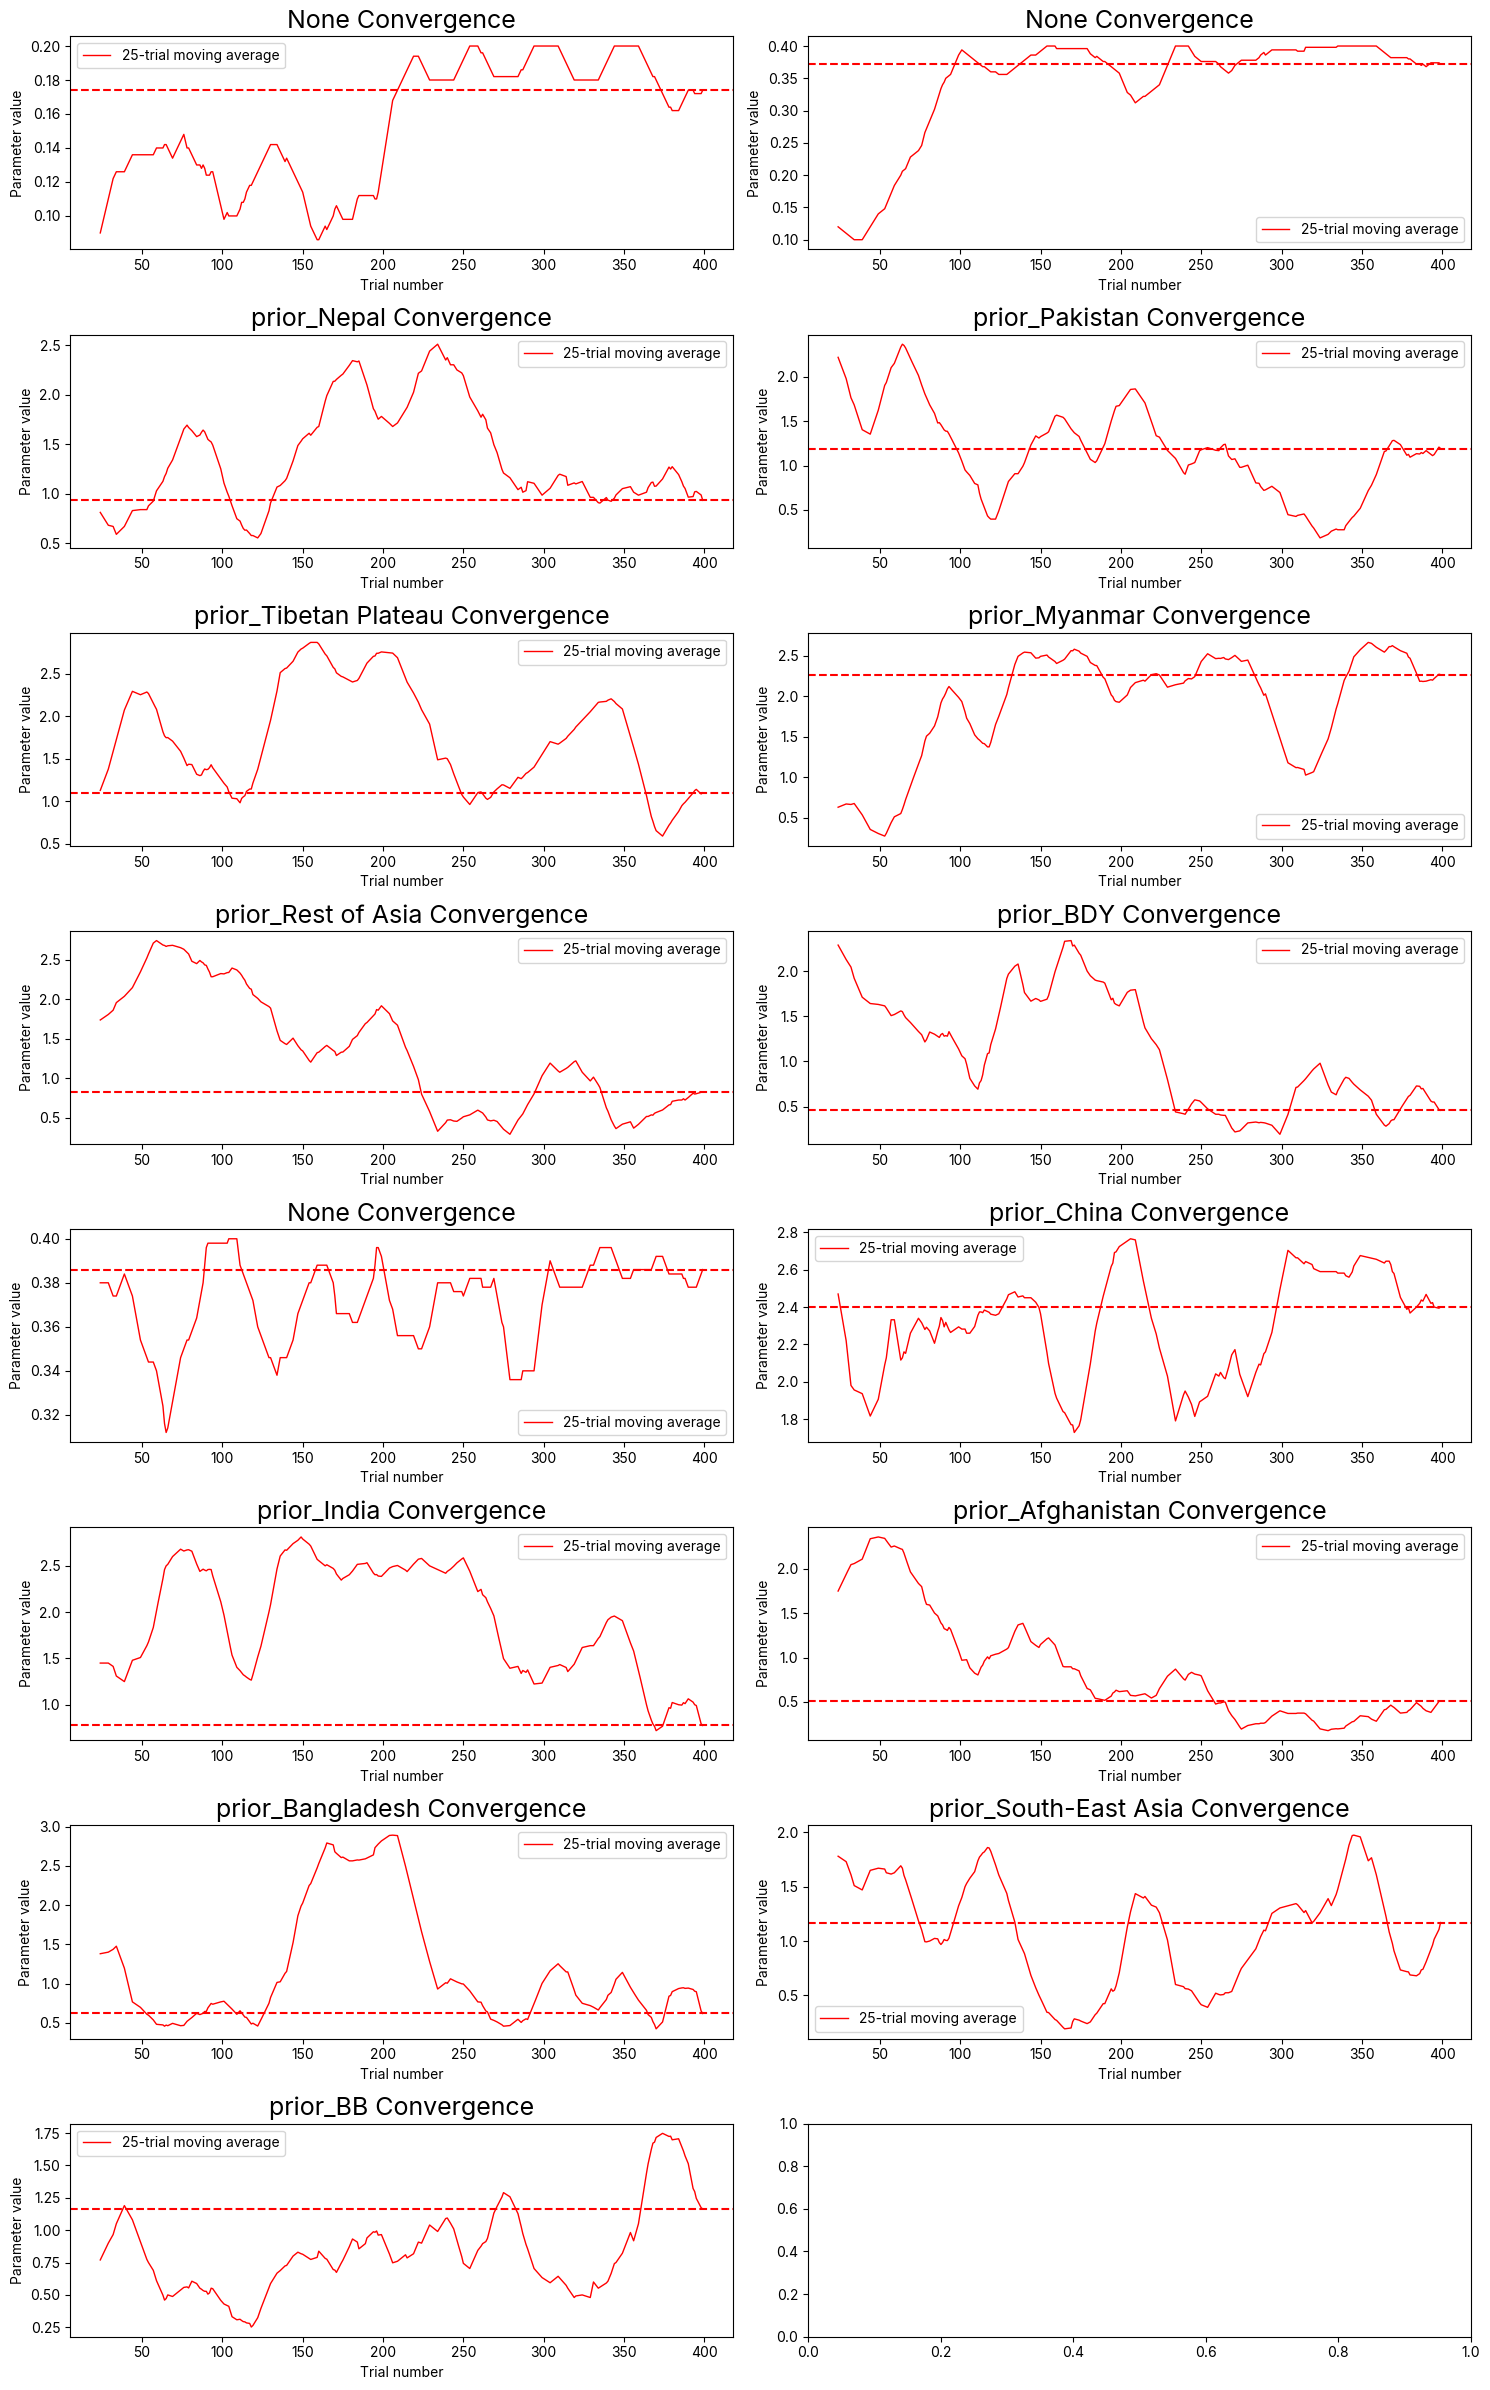

[I 2025-05-19 04:14:18,601] Trial 300 finished with value: 1.3795844199859706 and parameters: {'obs_instrument_error': 0.2, 'obs_trans_error': 0.4, 'prior_m_2': 1.6, 'prior_m_4': 0.05, 'prior_m_6': 1.6500000000000001, 'prior_m_8': 1.0, 'prior_m_10': 0.8500000000000001, 'prior_m_12': 1.6500000000000001, 'obs_rep_error': 0.35, 'prior_m_1': 2.6, 'prior_m_3': 1.7000000000000002, 'prior_m_5': 0.2, 'prior_m_7': 1.2000000000000002, 'prior_m_9': 1.35, 'prior_m_11': 0.7500000000000001}. Best is trial 237 with value: 1.3096597344299399.
[I 2025-05-19 04:14:19,062] Trial 310 finished with value: 1.5548196363112625 and parameters: {'obs_instrument_error': 0.15000000000000002, 'obs_trans_error': 0.35, 'prior_m_2': 1.2500000000000002, 'obs_rep_error': 0.35, 'prior_m_1': 2.8, 'prior_m_3': 1.85, 'prior_m_4': 0.45, 'prior_m_5': 0.3, 'prior_m_6': 2.1, 'prior_m_7': 0.15000000000000002, 'prior_m_8': 1.35, 'prior_m_9': 1.0, 'prior_m_10': 0.9500000000000001, 'prior_m_12': 0.25, 'prior_m_11': 0.1500000000000

In [118]:
"""Analyze how parameters converge over trials."""
param_history = {}

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        for param_name, param_value in trial.params.items():
            if param_name not in param_history:
                param_history[param_name] = []
            param_history[param_name].append(param_value)

# Create convergence plots for each parameter
n_params = len(param_history)
fig, axes = plt.subplots(
    (n_params + 1) // 2, 2, 
    figsize=(15, 3 * ((n_params + 1) // 2))
)
axes = axes.ravel()

for idx, (param_name, values) in enumerate(param_history.items()):
    ax = axes[idx]
    # ax.plot(values, 'b.-', alpha=0.5)
    ax.set_title(f'{param_map.get(param_name)} Convergence', size=18)
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Parameter value')
    
    # Add rolling mean
    window = min(25, len(values))
    rolling_mean = pd.Series(values).rolling(window=window).mean()
    ax.plot(rolling_mean, 'r-', linewidth=1, label=f'{window}-trial moving average')
    ax.axhline(rolling_mean.iloc[-1],color='r',ls='--')
    ax.legend()

plt.tight_layout()

# param_history = {}
# for trial in study1.trials:
#     if trial.state == optuna.trial.TrialState.COMPLETE:
#         for param_name, param_value in trial.params.items():
#             if param_name not in param_history:
#                 param_history[param_name] = []
#             param_history[param_name].append(param_value)

# for idx, (param_name, values) in enumerate(param_history.items()):
#     ax = axes[idx]
#     # ax.plot(values, 'b.-', alpha=0.5)
#     ax.set_title(f'{param_map.get(param_name)} Convergence', size=18)
#     ax.set_xlabel('Trial number')
#     ax.set_ylabel('Parameter value')
    
#     # Add rolling mean
#     window = min(25, len(values))
#     rolling_mean = pd.Series(values).rolling(window=window).mean()
#     ax.plot(rolling_mean, 'b-', linewidth=1, label=f'{window}-trial moving average')
#     ax.axhline(rolling_mean.iloc[-1],color='b',ls='--')
#     ax.legend()

# plt.tight_layout()


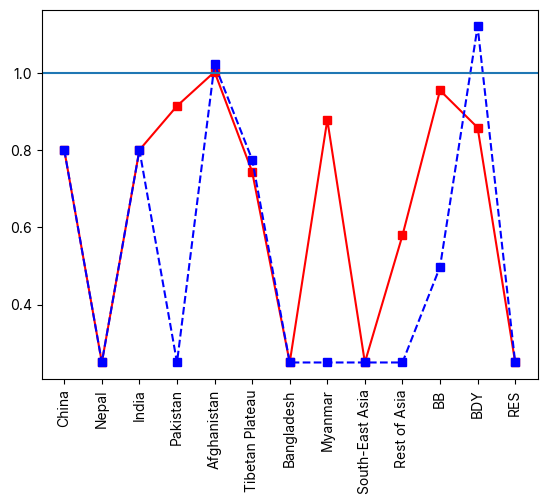

[W 2025-05-13 21:45:25,575] Trial 1321 failed with parameters: {} because of the following error: StorageInternalError('An exception is raised during the commit. This typically happens due to invalid data in the commit, e.g. exceeding max length. ').
Traceback (most recent call last):
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/sqlalchemy/engine/base.py", line 1965, in _exec_single_context
    self.dialect.do_execute(
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/sqlalchemy/engine/default.py", line 921, in do_execute
    cursor.execute(statement, parameters)
sqlite3.OperationalError: database is locked

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/storages/_rdb/storage.py", line 71, in _create_scoped_session
    session.commit()
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/sqla

In [197]:
plt.plot([1,2,3,4,5,6,7,8,9,10,11,12,13], m_post, marker='s',c='r')

plt.plot( [1,2,3,4,5,6,7,8,9,10,11,12,13], 
         study1.best_trial.user_attrs['metrics']['posterior_mean'], marker='s',c='b', ls='--')

plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13],[
    "China",
    "Nepal",
    "India",
    "Pakistan",
    "Afghanistan",
    "Tibetan Plateau",
    "Bangladesh",
    "Myanmar",
    "South-East Asia",
    "Rest of Asia",'BB','BDY','RES']
          ,rotation=90)

plt.axhline(1)

In [139]:
G.shape,  np.array(study1.best_trial.user_attrs['metrics']['posterior_mean']).reshape(-1,1).shape

((455, 12), (13, 1))

In [136]:
predictions = G @ m_post
observations = d

print(
    em.ErrorMetrics(predictions = predictions, observations = observations).get_metrics(['MB','RMSE','Rsp','RNP','KGE'])
    )
    
predictions = G @ np.array(study1.best_trial.user_attrs['metrics']['posterior_mean']).reshape(-1,1)
observations = d

print(
    em.ErrorMetrics(predictions = predictions, observations = observations).get_metrics(['MB','RMSE','Rsp','RNP','KGE'])
    )

{'MB': -0.61, 'RMSE': 4.53, 'Rsp': 0.62, 'RNP': 0.58, 'KGE': 0.45}


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 13 is different from 12)

In [73]:
AvgK = np.array(study.best_trial.user_attrs['results']['averaging_kernel'])
import cmaps

Tags =  ["China",
    "Nepal",
    "India",
    "Pakistan",
    "Afghanistan",
    "Tibetan Plateau",
    "Bangladesh",
    "Myanmar",
    "South-East Asia",
    "Rest of Asia",'BB','BDRES']

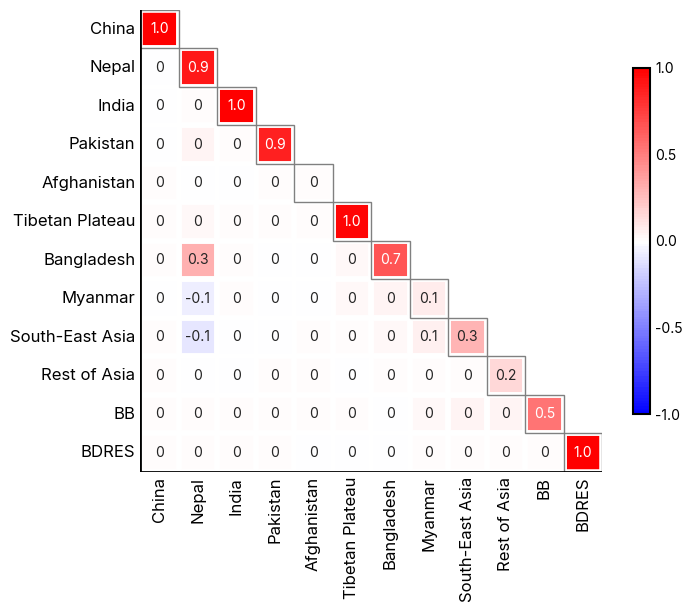

In [72]:
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

# Custom function to format labels
def custom_fmt(value):
    return f"{value:.0f}" if np.isclose(value, 0.0) else f"{value:.1f}"  # 0.0 → "0", others → 0.1f

# Apply formatting to each cell
formatted_labels = np.vectorize(custom_fmt)(np.round((AvgK),1) + 0)

# **Mask to show only upper or lower triangle, but KEEP diagonal**
show_upper = True  # Set to False for lower triangle
mask = np.triu(np.ones_like(AvgK, dtype=bool), k=1) if show_upper else np.tril(np.ones_like(AvgK, dtype=bool), k=-1)


norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Generate heatmap with mask (keeping diagonal), using norm
heatmap = sns.heatmap(AvgK, cmap=cmaps.MPL_bwr, annot=formatted_labels, fmt="", linewidths=0, square=True, 
                      cbar=True, annot_kws={"size": 10}, xticklabels=Tags,
                      yticklabels=Tags, ax=ax, mask=mask, 
                      cbar_kws={"shrink": 0.75, "aspect": 20}, norm=norm)

# Adjust tick positions but remove tick marks
ax.set_xticks(np.arange(len(Tags)) + 0.5)
ax.set_yticks(np.arange(len(Tags)) + 0.5)
ax.set_xticklabels(Tags, rotation=90, fontsize=12)
ax.set_yticklabels(Tags, rotation=0, fontsize=12)

# Completely remove tick marks but keep labels
ax.tick_params(axis="both", which="both", length=0)

# **Manually add thick borders** around the heatmap
#ax.axhline(y=0, color='black', linewidth=2)  # Top border
ax.axhline(y=AvgK.shape[0], color='black', linewidth=2)  # Bottom border
ax.axvline(x=0, color='black', linewidth=2)  # Left border
#ax.axvline(x=AvgK.shape[1], color='black', linewidth=2)  # Right border

# Adjust colorbar position & styling
cbar = heatmap.collections[0].colorbar
cbar.ax.set_frame_on(True)  # Add a border around the colorbar
cbar.outline.set_linewidth(1.5)  # Thicken the border

# Set discrete ticks centered around 0
cbar.set_ticks([-1,-0.5,0,0.5,1])
cbar.ax.tick_params(size=0)  # Remove tick marks on colorbar

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))  # Format tick labels

# Move colorbar slightly closer to heatmap
#cbar.ax.set_position([0.85, 0.2, 0.02, 0.6])  # Fine-tuned spacing
# **Outline only diagonal boxes**
for i in range(AvgK.shape[0]):  # Loop through diagonal elements
    rect = plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='black', lw=2)
    ax.add_patch(rect)


for i in range(AvgK.shape[0]):
    for j in range(AvgK.shape[1]):
        rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='w', lw=4)
        ax.add_patch(rect)

# Move colorbar slightly closer to heatmap
#cbar.ax.set_position([0.85, 0.2, 0.02, 0.6])  # Fine-tuned spacing
# **Outline only diagonal boxes**
for i in range(AvgK.shape[0]):  # Loop through diagonal elements
    rect = plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='gray', lw=1)
    ax.add_patch(rect)


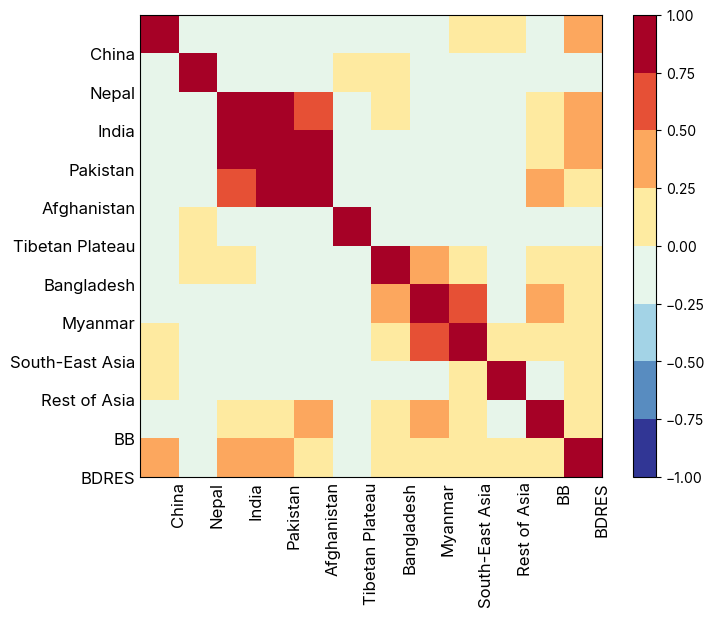

In [74]:
df = pd.DataFrame(G)

df.columns = cols

norm  = matplotlib.colors.BoundaryNorm(np.arange(-1,1.25,0.25), cmaps.MPL_RdYlBu_r.N)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

cc = ax.imshow(df.corr(), cmap =cmaps.MPL_RdYlBu_r, norm = norm)
fig.colorbar(cc)


# Adjust tick positions but remove tick marks
ax.set_xticks(np.arange(len(Tags)) + 0.5)
ax.set_yticks(np.arange(len(Tags)) + 0.5)
ax.set_xticklabels(Tags, rotation=90, fontsize=12)
ax.set_yticklabels(Tags, rotation=0, fontsize=12)

# Completely remove tick marks but keep labels
ax.tick_params(axis="both", which="both", length=0)


# Do combined seasonal inversion. combine anthro tags

In [56]:
data_sources = ['C14', 'RS', 'G20']

alldata1 = alldata.query('SOURCE in @data_sources')

In [57]:
G1 = alldata1[["BC_3D_AR" + str(suf) for suf in [1,2,3,6, 10]]] # China, Nepal, India, TP, Rest of Asia

G1['BC_3D_REST'] = alldata1[
["BC_3D_AR" + str(suf) for suf in [4,5,7,8,9]] # Pak, Afgh, Bangla, Myan, SEAsia
].sum(1)

G1 = G1.join(alldata1[
       ["BC_3D_" + suf for suf in ["BB", "BDRES"]]
        ]
       ).values

d = alldata1['BC_OBS'].values.reshape(-1,1)
G = G1.copy()

d.shape, G.shape

/glade/derecho/scratch/chayan/tmp/ipykernel_5408/3567800222.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G1['BC_3D_REST'] = alldata1[


((455, 1), (455, 8))

In [72]:
N_PARAMS = 8

def objective(trial):
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning) 

  
    obs_error = np.round(trial.suggest_float('obs_error', 0.05, 0.9, step=0.05),4)

    prior_error_dict = {}
    for i in range(1, N_PARAMS+1):
        prior_error_dict[f'prior_m_{i}'] = np.round(trial.suggest_float(
            f'prior_m_{i}', 0.05, 3, step=0.05), 4)

    prior_sigma = 1

    #G, d = return_Gd(alldata,  ['C14', 'RS','G20'])

    m_prior, Cd, Cm = prepare_inversion(G, d)

    #########################

    # Multiply all other diagonal elements by c_rest
    for i in range(1, N_PARAMS+1):
        Cm[i-1, i-1] *= (prior_error_dict[f'prior_m_{i}'] * m_prior[i-1]) ** 2

    floor = 0.05 * np.nanmedian(
    np.where(d < np.nanpercentile(d,100), d, np.nan)
    )
    sigmad = np.maximum(obs_error * d.squeeze(), floor)

    sigmad = obs_error * d.squeeze()
    Cd = np.diag(sigmad ** 2)

    inversion_results = constrained_bayesian_inversion(
        G=G, d_obs=d, m_prior=m_prior, Cd=Cd, Cm=Cm, lambda_reg=1, verbose=False)

    # Convert your results dictionary to JSON serializable format
    serialization_results = make_serializable(inversion_results)

    loss = (abs(inversion_results['J_obs']   / d.size         - 1.0) +
            abs(inversion_results['J_prior'] / m_prior.size   - 1.0))

    trial.set_user_attr("results", serialization_results)

    predictions_posterior = G @ inversion_results['posterior_mean']
    predictions_prior = G @ m_prior

    metrics_posterior = em.ErrorMetrics(predictions = predictions_posterior, observations = d).get_metrics(['KGE'])['KGE']
    trial.set_user_attr("KGE_posterior", metrics_posterior)
    
    metrics_prior = em.ErrorMetrics(predictions = predictions_prior, observations = d).get_metrics(['KGE'])['KGE']
    trial.set_user_attr("KGE_prior", metrics_prior)

    if metrics_posterior <= metrics_prior:
        raise optuna.TrialPruned()
    
    return loss


In [73]:

def optimize_parameters(n_trials):
    
    study_name = 'tpe_cmaes_seasonal_combined_cost'  # Unique identifier of the study.
    storage_path = '/glade/u/home/chayan/NASA_HMA_ouputs/INVERSION/New/inversion2/db_trials/'
    storage_name = f"sqlite:///{storage_path}{study_name}.db"

    timeout = 2
    
    study = optuna.create_study(
    study_name = study_name,
    direction='minimize', 
    storage=storage_name,
    load_if_exists = True,
    sampler = SwitchingSampler(switch_trial=1000, seed=None),
    pruner = MultiplePruners((DuplicateIterationPruner(), optuna.pruners.HyperbandPruner()))
    )

    # Check storage type and set timeout
    from optuna.storages._rdb.storage import RDBStorage
    
    if isinstance(study._storage, RDBStorage):
        study._storage.engine.pool_timeout = timeout
        study._storage.engine.pool_recycle = 3600

    try:
        study.optimize(
            objective, 
            n_trials=n_trials, 
            show_progress_bar=True,
            catch=(sqlite3.OperationalError,)  # Catch database locked errors
        )
    except Exception as e:
        print(f"Optimization failed with error: {e}")

    return study

from alembic import op
import sqlalchemy as sa


def upgrade() -> None:
    # Workaround for the problem
    bind = op.get_bind()
    inspector = sa.inspect(bind)
    if "_alembic_tmp_foo" in inspector.get_table_names():
        op.drop_table("_alembic_tmp_trial_values")
    
    # Schema Migration
    with op.batch_alter_table("foo") as batch_op:
        batch_op.alter_column("bar", nullable=True)
    
    # Data Migration
    raise Exception("An exception is raised during data migration")



In [74]:
# Run parallel optimization
n_trial_per_job = 1
n_of_jobs = 20

print('Trials asked : ',n_of_jobs * n_trial_per_job)
print('='*100)
time.sleep(5)

# Add error handling for parallel execution
try:
    r = Parallel(n_jobs=20, backend='loky',verbose=1)(
        delayed(optimize_parameters)(n_trial_per_job) for _ in range(n_of_jobs)
    )
except Exception as e:
    print(f"Parallel execution failed with error: {e}")

print('='*100)
print('DONE')

Trials asked :  20


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/samplers/_tpe/sampler.py:278: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/samplers/_tpe/sampler.py:289: ExperimentalWarning: ``group`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/samplers/_tpe/sampler.py:278: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/optuna/samplers/_tpe/sampler.py:289: ExperimentalWarning: ``group`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
/glade/work/chayan/co

[I 2025-05-15 08:44:30,561] Trial 22 pruned. 
[I 2025-05-15 08:44:33,228] Trial 42 pruned. 
[I 2025-05-15 08:44:34,347] Trial 53 pruned. 
[W 2025-05-15 08:44:40,899] Trial 61 failed with parameters: {'obs_error': 0.05, 'prior_m_1': 0.25, 'prior_m_2': 1.05, 'prior_m_3': 2.6} because of the following error: StorageInternalError('An exception is raised during the commit. This typically happens due to invalid data in the commit, e.g. exceeding max length. ').
Traceback (most recent call last):
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/sqlalchemy/engine/base.py", line 1965, in _exec_single_context
    self.dialect.do_execute(
  File "/glade/work/chayan/conda-envs/gpu/lib/python3.9/site-packages/sqlalchemy/engine/default.py", line 921, in do_execute
    cursor.execute(statement, parameters)
sqlite3.OperationalError: database is locked

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/glade/work/chaya

[I 2025-05-15 08:47:14,506] Using an existing study with name 'tpe_cmaes_seasonal_combined_cost' instead of creating a new one.
[I 2025-05-15 08:47:14,507] Using an existing study with name 'tpe_cmaes_seasonal_combined_cost' instead of creating a new one.
[I 2025-05-15 08:47:14,508] Using an existing study with name 'tpe_cmaes_seasonal_combined_cost' instead of creating a new one.
[I 2025-05-15 08:47:14,508] Using an existing study with name 'tpe_cmaes_seasonal_combined_cost' instead of creating a new one.
  0%|          | 0/1 [00:00<?, ?it/s]

[I 2025-05-15 08:44:32,293] Trial 28 pruned. 
[I 2025-05-15 08:44:34,349] Trial 47 pruned. 
[I 2025-05-15 08:44:42,206] Trial 63 pruned. 
[I 2025-05-15 08:44:47,626] Trial 90 pruned. 
[I 2025-05-15 08:44:50,025] Trial 110 pruned. 
[I 2025-05-15 08:44:56,346] Trial 138 pruned. 
[I 2025-05-15 08:44:59,793] Trial 152 pruned. 
[I 2025-05-15 08:45:01,713] Trial 173 pruned. 
[I 2025-05-15 08:45:09,332] Trial 186 pruned. 
[I 2025-05-15 08:45:10,466] Trial 202 pruned. 
[I 2025-05-15 08:44:31,628] Trial 24 pruned. 
[I 2025-05-15 08:44:34,442] Trial 43 pruned. 
[I 2025-05-15 08:44:39,545] Trial 62 pruned. 
[I 2025-05-15 08:44:43,956] Trial 79 pruned. 
[I 2025-05-15 08:44:48,126] Trial 97 pruned. 
[I 2025-05-15 08:44:54,448] Trial 114 pruned. 
[I 2025-05-15 08:44:58,929] Trial 151 pruned. 
[I 2025-05-15 08:45:00,932] Trial 168 pruned. 
[I 2025-05-15 08:45:01,996] Trial 176 pruned. 
[I 2025-05-15 08:45:09,902] Trial 188 pruned. 
[I 2025-05-15 08:44:33,309] Trial 20 pruned. 
[I 2025-05-15 08:44:39,

Best trial: 216. Best value: 0.395383: 100%|██████████| 1/1 [00:03<00:00,  3.36s/it]


DONE


Best trial: 216. Best value: 0.395383: 100%|██████████| 1/1 [00:03<00:00,  3.49s/it]
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    3.8s finished


In [75]:
study_name = 'tpe_cmaes_seasonal_combined_cost'
storage_path = '/glade/u/home/chayan/NASA_HMA_ouputs/INVERSION/New/inversion2/db_trials/'
storage_name = f"sqlite:///{storage_path}{study_name}.db"

study = optuna.load_study(study_name=study_name, storage=storage_name)


In [76]:
trials = study.get_trials(deepcopy=False)
completed_trials = list(
    [
        trial
        for trial in trials
        if trial.state not in {optuna.trial.TrialState.RUNNING, optuna.trial.TrialState.WAITING, optuna.trial.TrialState.FAIL} and trial.number < 2500
    ]
)
if len(trials) != len(completed_trials):
    print(f"Some trials are not completed, will keep {len(completed_trials)} out of {len(trials)}")
    optuna.delete_study(study_name=study_name, storage=storage_name)
    study = optuna.create_study(
        study_name=study_name, storage=storage_name,
        load_if_exists=True,
        direction="minimize",
    )
    study.add_trials(completed_trials)

Some trials are not completed, will keep 223 out of 225


[I 2025-05-15 08:47:24,890] A new study created in RDB with name: tpe_cmaes_seasonal_combined_cost


In [77]:
df = study.trials_dataframe().drop(columns = ['datetime_start','datetime_complete','duration'])
df

,number,value,params_obs_error,params_prior_m_1,params_prior_m_2,params_prior_m_3,params_prior_m_4,params_prior_m_5,params_prior_m_6,params_prior_m_7,params_prior_m_8,user_attrs_KGE_posterior,user_attrs_KGE_prior,user_attrs_results,state
0,0,NaN,0.25,0.85,2.15,2.00,2.30,0.45,2.90,1.60,2.30,0.44,0.51,"{'num_observations': 455, 'num_state_parameter...",PRUNED
1,1,NaN,0.45,2.55,0.85,2.45,2.55,1.70,1.40,2.80,0.65,0.44,0.51,"{'num_observations': 455, 'num_state_parameter...",PRUNED
2,2,NaN,0.60,2.55,1.05,2.90,2.90,0.75,2.70,1.10,2.35,0.44,0.51,"{'num_observations': 455, 'num_state_parameter...",PRUNED
3,3,NaN,0.80,2.35,2.75,2.10,1.65,2.90,0.40,2.55,2.55,0.45,0.51,"{'num_observations': 455, 'num_state_parameter...",PRUNED
4,4,NaN,0.20,0.10,1.05,2.55,0.40,2.30,2.90,1.80,1.80,0.44,0.51,"{'num_observations': 455, 'num_state_parameter...",PRUNED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,218,0.647443,0.90,0.55,0.60,1.70,0.10,0.25,1.85,2.10,1.65,0.36,-0.02,"{'num_observations': 455, 'num_state_parameter...",COMPLETE
219,219,2.185644,0.55,0.85,2.55,2.15,1.95,1.25,2.80,1.35,2.00,0.36,-0.02,"{'num_observations': 455, 'num_state_parameter...",COMPLETE
220,220,5.569095,0.35,0.80,2.30,2.80,1.35,2.55,1.55,1.40,1.20,0.36,-0.02,"{'num_observations': 455, 'num_state_parameter...",COMPLETE
221,221,8.309029,0.30,1.80,3.00,1.35,2.05,0.10,1.55,1.05,1.60,0.36,-0.02,"{'num_observations': 455, 'num_state_parameter...",COMPLETE


In [119]:
# ┌────────────────────────────────────────────────────────────────────────────┐
# │ 1) Baseline Optuna objective                                            │
# └────────────────────────────────────────────────────────────────────────────┘
def objective_baseline(trial):
    # 1. Sample emission scalings x
    x = np.array([trial.suggest_float(f"x{i}", 0.25, 5.0) for i in range(12)])

    # 2. Fixed error & prior covariances
    sigma_y = 0.1 * y_obs
    R_inv   = np.diag(1.0 / sigma_y**2)          # △ fixed R
    P_inv   = np.diag(np.ones_like(x))           # △ fixed P (σ_x=1)

    # 3. Compute cost
    r       = y_obs - G @ x
    J_obs   = float(r.T @ R_inv @ r)
    d       = x - x_prior
    J_prior = float(d.T @ P_inv @ d)

    return J_obs + J_prior

# ┌────────────────────────────────────────────────────────────────────────────┐
# │ 2) Hierarchical hybrid Optuna → SLSQP objective                          │
# └────────────────────────────────────────────────────────────────────────────┘
# — You’ll need to have these helpers defined once:
#    build_R(σy, τ, idx), build_P(σx, dim), and J_hyper((lnσy,lnσx,τ))

def objective_hierarchical(trial):
    # 1. Sample hyper-parameters instead of x directly
    lnσy = trial.suggest_float("ln_sigma_y", np.log(0.3), np.log(3.0))  # △
    lnσx = trial.suggest_float("ln_sigma_x", np.log(0.5), np.log(2.0))  # △
    τ    = trial.suggest_float("tau",        0.0,        5.0)          # △
    σy, σx = np.exp(lnσy), np.exp(lnσx)

    # 2. Build R⁻¹ and P⁻¹ from θ (cached for speed)
    R_inv = build_R(σy, τ, resid_idx)                     # △
    P_inv = build_P(σx, G.shape[1])                       # △

    # 3. Inner SLSQP to find best x for this θ
    def J_inner(x):
        r = y_obs - G @ x
        return float(r.T @ R_inv @ r + (x - x_prior).T @ P_inv @ (x - x_prior))  # △

    res   = minimize(J_inner, x_prior, method="SLSQP",
                     jac="2-point", options={"maxiter":300})  # △
    x_opt = res.x

    # 4. Add hyper-prior penalty to form the total cost
    J_total = res.fun + J_hyper((lnσy, lnσx, τ))           # △

    # 5. (Optional) Log diagnostics for later plotting
    trial.set_user_attr("J_obs",   float((y_obs - G@x_opt).T @ R_inv @ (y_obs - G@x_opt)))
    trial.set_user_attr("J_prior", float((x_opt - x_prior).T @ P_inv @ (x_opt - x_prior)))
    trial.set_user_attr("sigma_y", σy)
    trial.set_user_attr("sigma_x", σx)

    return J_total



In [ ]:
from optuna.storages import RDBStorage

storage = RDBStorage(
        url="postgresql+psycopg2://localhost/optuna",
        engine_kwargs=dict(pool_size=20, max_overflow=0, pool_pre_ping=True),
    )

study_name = "tpe_cmaes_seasonal_cost"

def optimize_parameters(n_trials, study_name = study_name):

    # storage = RDBStorage(
    #     url=storage_url,
    #     engine_kwargs=dict(pool_size=20, max_overflow=0, pool_pre_ping=True),
    # )
    
    study = optuna.create_study(
        study_name      = study_name,
        direction       = "minimize",
        storage         = storage,
        load_if_exists  = True,
        sampler         = SwitchingSampler(switch_trial=1000, seed=5),
        pruner          = MultiplePruners(
            (DuplicateIterationPruner(), optuna.pruners.HyperbandPruner(), EarlyStoppingPruner(
                    min_trials=100,
                    patience=100,
                    min_delta=0.001
                ))
        ),
    )

    # study.enqueue_trial( {'obs_error': 0.1, 'prior_m_2': 1, 'prior_m_4':1 ,
    #                       'prior_m_6': 1, 'prior_m_8': 1,
    #                       'prior_m_10': 1, 'prior_m_12': 1, 'prior_m_1': 1, 'prior_m_3': 1,
    #                       'prior_m_5': 1, 'prior_m_7': 1, 'prior_m_9': 1, 'prior_m_11': 1})
    
    
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    #return study


#################################################################
# Run parallel optimization
n_trial_per_job = 80
n_of_jobs = 10

print('Trials asked : ',n_of_jobs * n_trial_per_job)
print('='*100)
time.sleep(2)

# Add error handling for parallel execution
try:
    r = Parallel(n_jobs=n_of_jobs, backend='loky',verbose=1)(
        delayed(optimize_parameters)(n_trial_per_job) for _ in range(n_of_jobs)
    )
except Exception as e:
    print(f"Parallel execution failed with error: {e}")

print('='*100)
print('DONE')
